# Martian Spiders

In [1]:
import os
import sys
import matplotlib.pyplot as plt
from brokenaxes import brokenaxes 
import pdb
import numpy as np
import os as os_module
from scipy.integrate import solve_ivp
import pandas as pd
from matplotlib import ticker
import scipy as sp
from scipy.integrate import cumulative_trapezoid, trapezoid, odeint, solve_bvp, solve_ivp
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import colormaps
import matplotlib.ticker as mtick
from matplotlib.ticker import EngFormatter, LogLocator, FuncFormatter, NullFormatter, FixedLocator, StrMethodFormatter, LogFormatter, LogFormatterSciNotation, LogFormatterExponent, LogFormatterMathtext, FixedFormatter
from matplotlib.lines import lineStyles
import cmocean
import cmocean.cm as cmo
from matplotlib.colors import LogNorm
from IPython.display import clear_output
import matplotlib.patheffects as pe
from matplotlib.collections import LineCollection
from labellines import labelLines
from itertools import cycle

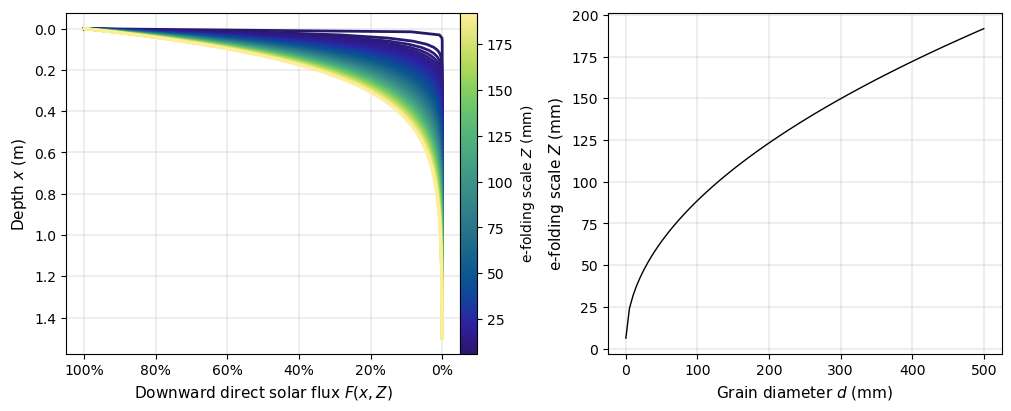

In [2]:
# Chinnerny et al. (2020) found e-folding of solar radiation penetration in CO2 ice relates to grain size in the following way.
 
a = 5.37 # (mm)
b_CO2 = 0.0144 # (mm)
d = np.linspace(1e-2, 500, 100) # grain diameter (mm)
# CO2 ice slab thicknesses: ~0.5-1 m.
x = np.linspace(0, 1.5, 100)*1e3 # depth (mm)

Z = a + np.sqrt(d/b_CO2) # e-folding scale 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# and downward direct energy flux F(x,Z) as a percentage of total radiation is given by
colors = cmocean.cm.haline(np.linspace(0, 1, len(Z)))
for i, z in enumerate(Z):
    F = np.exp(-x / z)
    ax1.plot(F*1e2, x/1e3, lw=2, color=colors[i], label=f'$Z={z:.0f}$ mm')
ax1.set_ylabel('Depth $x$ (m)', fontsize=11)
ax1.set_xlabel('Downward direct solar flux $F(x,Z)$', fontsize=11)
ax1.xaxis.set_major_formatter(mtick.PercentFormatter())
ax1.grid(lw=0.3)
ax1.invert_yaxis()
ax1.invert_xaxis()
sm = plt.cm.ScalarMappable(cmap=cmocean.cm.haline)
sm.set_array(Z)
fig.colorbar(sm, ax=ax1, label='e-folding scale $Z$ (mm)', orientation='vertical', shrink=1, pad=0)
# ax1.legend(loc='lower left', fontsize=10, frameon=True, fancybox=True, edgecolor='black', facecolor='w')

ax2.plot(d, Z, color='k', lw=1)
ax2.set_xlabel('Grain diameter $d$ (mm)', fontsize=11)
ax2.set_ylabel('e-folding scale $Z$ (mm)', fontsize=11)
ax2.grid(lw=0.3)


In [3]:
# What depths correspond to 20%, 50%, 90%, and 99% of the flux for a given grain size?
thresholds = [0.8, 0.5, 0.2, 0.1, 0.01]
z = Z[50] # grain size (mm)
depths = {p:-z*np.log(p)/1e3 for p in thresholds}
print(f"Grain size: ~{d[50]:.0f} mm, \ne-folding scale: ~{z:.0f} mm")
print(f"___________________ \n20% flux depth: {depths[0.8]:.3f} m")
print(f"50% flux depth: {depths[0.5]:.3f} m")
print(f"80% flux depth: {depths[0.2]:.3f} m")
print(f"90% flux depth: {depths[0.1]:.3f} m")
print(f"99% flux depth: {depths[0.01]:.3f} m \n___________________")

Grain size: ~253 mm, 
e-folding scale: ~138 mm
___________________ 
20% flux depth: 0.031 m
50% flux depth: 0.096 m
80% flux depth: 0.222 m
90% flux depth: 0.317 m
99% flux depth: 0.635 m 
___________________


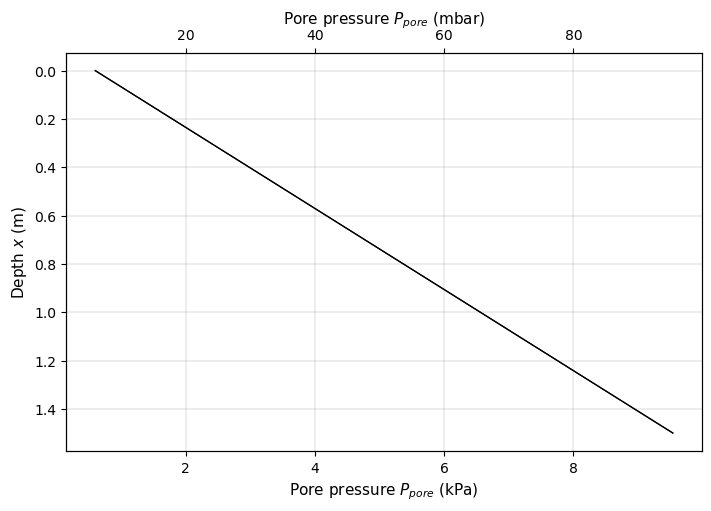

In [4]:
# Evolution of substrate pore pressure with depth

P_surf = 600 # (Pa) surface pressure on Mars
density_ice = 1606 # (kg/m3)
g = 3.71 # (m/s2)

P_pore = P_surf + density_ice * g * x/1e3 # (Pa) for a depth x (mm)
P_pore_kPa = P_pore/1e3
P_pore_mbar = P_pore_kPa*10

fig, ax1 = plt.subplots(figsize=(7, 5), constrained_layout=True)
ax2 = ax1.twiny()

ax1.plot(P_pore_kPa, x/1e3, color='k', lw=0.9)
ax2.plot(P_pore_mbar, x/1e3, color='k', lw=0.9)
ax1.set_ylabel('Depth $x$ (m)', fontsize=11)
ax1.set_xlabel('Pore pressure $P_{pore}$ (kPa)', fontsize=11)
ax2.set_xlabel('Pore pressure $P_{pore}$ (mbar)', fontsize=11)

ax1.grid(color='k', lw=0.1)
ax1.invert_yaxis()

Text(0.5, 1.0, 'gas production (GP) radius as a function of GP area')

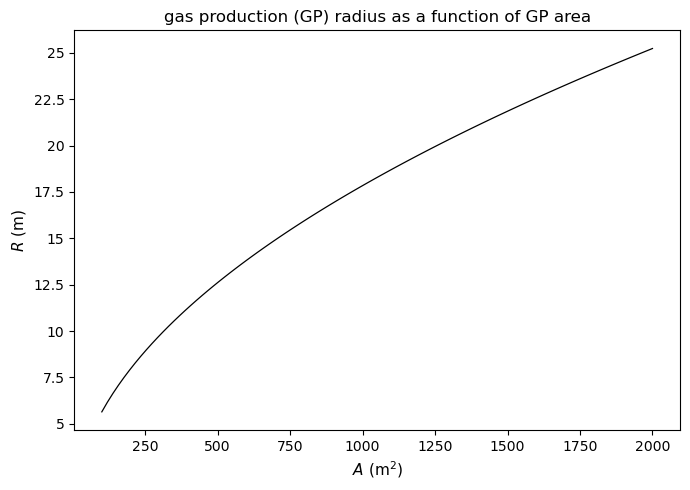

In [31]:
# area of a circle is A = pi*r**2

areas = np.linspace(1e2,2e3, 100) # (m2)
R = np.sqrt(areas/np.pi) # (m)

fig, ax = plt.subplots(layout='tight', figsize=(7,5))
# ax2 = ax.twiny()

ax.plot(areas, R, color='k', lw=0.9)
# ax2.plot(areas/1e6, R, color='k', lw=0.9)
ax.set_xlabel('$A$ (m$^2$)', fontsize=11)
# ax2.set_xlabel('$A$ (km$^2$)', fontsize=11)
ax.set_ylabel('$R$ (m)', fontsize=11) 
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:g}'))
ax.set_title('gas production (GP) radius as a function of GP area', fontsize=12)

Text(0.5, 1.0, 'critical pressure for fracture and eruption for r/R=1')

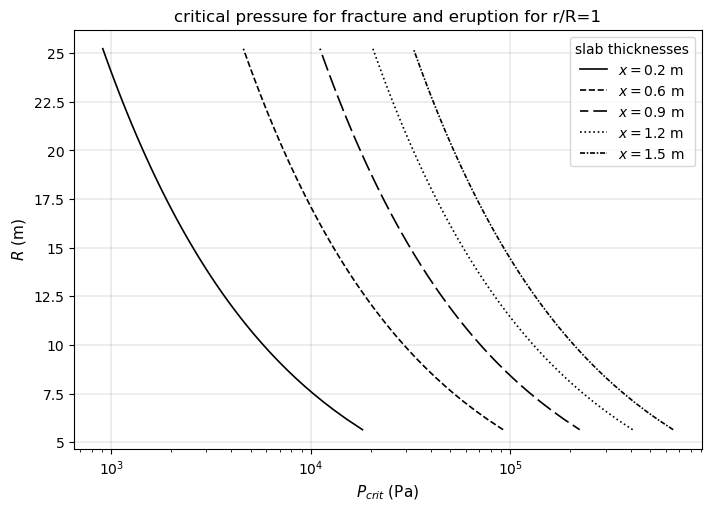

In [64]:
# critical pressure for fracture and eruption from Portyankina et al. (2010)'s plate-mechanics model 

sigma = 12.3e6 # (Pa) tensile strength of CO2 ice
nu = 0.544 # Poisson's ratio for CO2 ice
# R: either define a constant R or run the previous cell
r = R
# x = 1.5e3 # (mm) slab thickness
linestyles = ['-', '--', (5, (10,3)), ':', (0, (3, 1, 1, 1))]

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
for i, x in enumerate(np.linspace(0.25, 1.5, 5)):
    P_crit = 8 * sigma * (x)**2 / (3 * r**2) * 1/(4 - (1 - nu) * (r/R)**2 + 4 * (1 - nu) * np.log(R/r))
    ax.semilogx(P_crit, r, color='k', lw=1.2, ls=linestyles[i], label=f'$x={x:.1f}$ m')

ax.set_xlabel('$P_{crit}$ (Pa)', fontsize=11)
ax.set_ylabel('$R$ (m)', fontsize=11)
ax.grid(color='k', lw=0.1)
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:g}'))
ax.xaxis.set_major_formatter(LogFormatterSciNotation(base=10.0, labelOnlyBase=False))
ax.legend(title='slab thicknesses')
# ax.invert_yaxis()
ax.set_title('critical pressure for fracture and eruption for r/R=1', fontsize=12)

In [29]:
r

array([ 5.64189584,  6.1595427 ,  6.63693784,  7.08222574,  7.50112652,
        7.89784   ,  8.27555764,  8.63677208,  8.98347425,  9.31728432,
        9.63954173,  9.95136887, 10.25371737, 10.54740241, 10.8331286 ,
       11.11150993, 11.38308528, 11.6483307 , 11.9076692 , 12.16147866,
       12.41009834, 12.65383414, 12.89296305, 13.12773681, 13.35838506,
       13.58511792, 13.80812828, 14.02759367, 14.24367796, 14.45653276,
       14.66629868, 14.87310642, 15.07707771, 15.27832615, 15.47695795,
       15.67307261, 15.86676346, 16.05811821, 16.24721939, 16.43414481,
       16.61896787, 16.80175797, 16.98258073, 17.16149836, 17.33856983,
       17.51385113, 17.68739548, 17.85925352, 18.02947348, 18.19810132,
       18.36518089, 18.53075408, 18.69486091, 18.85753966, 19.01882698,
       19.17875797, 19.33736629, 19.49468421, 19.65074274, 19.80557164,
       19.95919952, 20.11165391, 20.2629613 , 20.41314719, 20.56223616,
       20.71025189, 20.85721724, 21.00315426, 21.14808422, 21.29